<a href="https://colab.research.google.com/github/Alan-O-R/CP1_Semestre2/blob/main/Desafio_Final_Energia_ONS_API_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Desafio Final — Análise de Dados de Energia com API Pública

**Curso:** Ciência da Computação  
**Disciplina:** Soluções em Energias Renováveis e Sustentáveis

## Situação-problema

Uma equipe de planejamento energético precisa analisar o comportamento da carga elétrica de uma região atendida pelo Sistema Interligado Nacional (SIN).

Os dados serão obtidos diretamente de uma API pública do **Operador Nacional do Sistema Elétrico (ONS)**. A conexão com a API e a preparação inicial do JSON já estão fornecidas. A partir daí, sua equipe deverá construir o DataFrame, organizar os dados, criar recortes, calcular indicadores, produzir gráficos e elaborar um relatório técnico.

> Todos os códigos, resultados, gráficos e respostas devem permanecer neste mesmo Notebook.

## 1. Fonte dos dados

API pública de **Carga Verificada do ONS**:

- Portal: https://dados.ons.org.br/
- Conjunto de dados: https://dados.ons.org.br/dataset/carga-energia-verificada

Neste notebook será utilizada inicialmente a área **SP — São Paulo**, no período de **01/08/2025 a 07/08/2025**.

## 2. Bibliotecas

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Consulta à API

Esta célula está pronta. Não é necessário conhecer `requests` para realizar o desafio.

In [2]:
url = "https://apicarga.ons.org.br/prd/cargaverificada"

parametros = {
    "dat_inicio": "2025-08-01",
    "dat_fim": "2025-08-07",
    "cod_areacarga": "SP"
}

response = requests.get(url, params=parametros, timeout=30)

print("Status:", response.status_code)
print("URL:", response.url)

response.raise_for_status()
dados_json = response.json()

Status: 200
URL: https://apicarga.ons.org.br/prd/cargaverificada?dat_inicio=2025-08-01&dat_fim=2025-08-07&cod_areacarga=SP


## 4. Preparação inicial do JSON

A célula abaixo localiza a lista principal de registros retornada pela API e a armazena em `registros`.

In [3]:
if isinstance(dados_json, list):
    registros = dados_json

elif isinstance(dados_json, dict):
    chaves_com_lista = [
        chave for chave, valor in dados_json.items()
        if isinstance(valor, list)
    ]

    if not chaves_com_lista:
        raise ValueError("A resposta não contém uma lista de registros.")

    chave_registros = chaves_com_lista[0]
    registros = dados_json[chave_registros]
    print("Chave utilizada:", chave_registros)

else:
    raise TypeError("Formato de JSON não reconhecido.")

print("Tipo:", type(registros))
print("Quantidade de registros:", len(registros))

if registros:
    print("\nPrimeiro registro:")
    print(registros[0])

Tipo: <class 'list'>
Quantidade de registros: 336

Primeiro registro:
{'cod_areacarga': 'SP', 'din_atualizacao': '2026-08-14T05:58:29.574Z', 'dat_referencia': '2025-08-01', 'din_referenciautc': '2025-08-01T03:30:00.000Z', 'val_cargaglobal': 15913.618, 'val_cargaglobalcons': 15913.618, 'val_cargaglobalsmmgd': 15892.488, 'val_cargasupervisionada': 14421.112, 'val_carganaosupervisionada': 1471.3759, 'val_cargammgd': 21.13, 'val_consistencia': 0}


In [4]:
type(registros)

list

In [5]:
registros

[{'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T03:30:00.000Z',
  'val_cargaglobal': 15913.618,
  'val_cargaglobalcons': 15913.618,
  'val_cargaglobalsmmgd': 15892.488,
  'val_cargasupervisionada': 14421.112,
  'val_carganaosupervisionada': 1471.3759,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:00:00.000Z',
  'val_cargaglobal': 15251.414,
  'val_cargaglobalcons': 15251.414,
  'val_cargaglobalsmmgd': 15230.284,
  'val_cargasupervisionada': 13758.101,
  'val_carganaosupervisionada': 1472.184,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:30:00.000Z',
  'val_cargaglobal': 14606.733,
  'val_carga

# A partir daqui, o trabalho é da equipe

## DESAFIO 1 — Construção e inspeção do DataFrame

1. Crie um DataFrame Pandas chamado `dados` a partir de `registros`.
2. Exiba os primeiros registros.
3. Determine a quantidade de linhas e colunas.
4. Liste os nomes dos atributos.
5. Utilize `info()`.
6. Utilize `describe()`.
7. Em Markdown, identifique quais atributos representam data/hora, área de carga e valor de carga.

**Antes de prosseguir, compreenda a estrutura efetivamente retornada pela API.**

In [6]:
dados = pd.DataFrame(registros)

In [7]:
dados.head()

,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0


In [8]:
linhas, colunas = dados.shape
print(f"\nQuantidade de linhas: {linhas}")
print(f"Quantidade de colunas: {colunas}")


Quantidade de linhas: 336
Quantidade de colunas: 11


In [9]:
dados.columns

Index(['cod_areacarga', 'din_atualizacao', 'dat_referencia',
       'din_referenciautc', 'val_cargaglobal', 'val_cargaglobalcons',
       'val_cargaglobalsmmgd', 'val_cargasupervisionada',
       'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia'],
      dtype='object')

In [10]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cod_areacarga               336 non-null    object 
 1   din_atualizacao             336 non-null    object 
 2   dat_referencia              336 non-null    object 
 3   din_referenciautc           336 non-null    object 
 4   val_cargaglobal             336 non-null    float64
 5   val_cargaglobalcons         336 non-null    float64
 6   val_cargaglobalsmmgd        336 non-null    float64
 7   val_cargasupervisionada     336 non-null    float64
 8   val_carganaosupervisionada  336 non-null    float64
 9   val_cargammgd               336 non-null    float64
 10  val_consistencia            336 non-null    int64  
dtypes: float64(6), int64(1), object(4)
memory usage: 29.0+ KB


In [11]:
dados.describe()

,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
count,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.0
mean,17870.828981,17870.828981,16953.421626,15495.799695,1457.621862,917.407249,0.0
std,3029.042438,3029.042438,2962.721503,2982.650359,34.888571,1253.581141,0.0
min,12139.253000,12139.253000,11549.664000,10054.455000,1391.990800,21.130000,0.0
25%,15110.533375,15110.533375,14457.604250,12990.878500,1433.112575,21.130000,0.0
50%,18199.128500,18199.128500,17045.260000,15611.629500,1453.981650,21.196900,0.0
75%,20386.629500,20386.629500,18931.679500,17502.643500,1479.430775,1793.579475,0.0
max,23185.312000,23185.312000,23164.182000,21717.934000,1538.274700,3736.009800,0.0


In [12]:
print(f"""
Dados da data/hora:
- dat_referencia
Dados da área de carga:
- cod_areacarga
Dados do valor da carga:
- val_cargaglobal
""")


Dados da data/hora:
- dat_referencia
Dados da área de carga:
- cod_areacarga
Dados do valor da carga:
- val_cargaglobal



## DESAFIO 2 — Organização dos dados

1. Renomeie os principais atributos com nomes mais simples.
2. Crie um novo DataFrame contendo apenas os atributos necessários.
3. Verifique valores ausentes.
4. Caso existam, informe quantos há em cada atributo relevante.
5. Verifique se a variável de carga está em formato numérico.
6. Verifique como a data/hora está representada.
7. Registre em Markdown qualquer decisão de tratamento.

In [13]:
dados_renomeando = dados.rename(columns={
    'dat_referencia': 'data',
    'din_referenciautc': 'horario',
    'cod_areacarga': 'regiao',
    'val_cargaglobal': 'carga'
})
      #   'cod_areacarga', 'din_atualizacao', 'dat_referencia',
      #  'din_referenciautc', 'val_cargaglobal', 'val_cargaglobalcons',
      #  'val_cargaglobalsmmgd', 'val_cargasupervisionada',
      #  'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia'

In [14]:
dados_novo = dados_renomeando[['data', 'regiao', 'carga','horario']].copy()
dados_novo.head()
dados_novo.shape

(336, 4)

In [15]:
dados_novo.head()

,data,regiao,carga,horario
0,2025-08-01,SP,15913.618,2025-08-01T03:30:00.000Z
1,2025-08-01,SP,15251.414,2025-08-01T04:00:00.000Z
2,2025-08-01,SP,14606.733,2025-08-01T04:30:00.000Z
3,2025-08-01,SP,14182.290,2025-08-01T05:00:00.000Z
4,2025-08-01,SP,13838.488,2025-08-01T05:30:00.000Z


In [16]:
dados_novo.isnull().sum()

,0
data,0
regiao,0
carga,0
horario,0


In [17]:
dados_novo['carga'].dtype

dtype('float64')

In [18]:
print('Os dados de data esta representado em ano/mes/dia')

Os dados de data esta representado em ano/mes/dia


Verificando se tem dados faltando (dados_novo.isnull().sum()):
- não teve nenhum dado faltando
Diagnóstico do Tipo de Dado (dtype):
- A verificação do tipo interno dos dados através de dados_novo['carga'].dtype confirmou o formato float64 (numérico contínuo).

Decisão de Tratamento:
- Nenhuma conversão adicional é necessária. O atributo já se encontra em formato numérico decimal adequado, estando pronto para a aplicação de funções de agregação estatística (como min(), max(), mean() e describe()).

## DESAFIO 3 — Indicadores da carga elétrica

Calcule:

1. carga mínima;
2. carga máxima;
3. carga média;
4. mediana;
5. amplitude entre máximo e mínimo;
6. quantidade total de medições.

Depois responda:

**O valor máximo está muito distante do comportamento médio observado? Justifique com os indicadores calculados.**

In [19]:
carga_minima = dados['val_cargaglobal'].min()
carga_maxima = dados['val_cargaglobal'].max()
carga_media = dados['val_cargaglobal'].mean()
mediana = dados['val_cargaglobal'].median()
amplitude = carga_maxima - carga_minima
quantidade_total = len(dados)

In [20]:
print(f'A carga minima: {carga_minima}')
print(f'A carga maxima: {carga_maxima}')
print(f'A carga media: {carga_media}')
print(f'A mediana: {mediana}')
print(f'A amplitude: {amplitude}')
print(f'A quantidade total: {quantidade_total}')

A carga minima: 12139.253
A carga maxima: 23185.312
A carga media: 17870.828980654762
A mediana: 18199.1285
A amplitude: 11046.059000000001
A quantidade total: 336


Não, o valor máximo não está excessivamente nem anormalmente distante da média, estando dentro da variação esperada para uma curva de carga de energia elétrica.
- Diferença para a Média: carga maxima(23.185,31) - carga media(17.870,83) = 5.314,48.
- O valor máximo é aproximadamente 29,7\% maior que a carga média.
- Em sistemas elétricos (como a rede do ONS), variações de 25\% a 40\% entre a média do dia e o horário de pico (tarde/noite) são padrão devido à rotina de consumo comercial, industrial e residencial.

## DESAFIO 4 — Períodos de alta demanda

Considere como **alta demanda** os registros com carga superior a **90% da carga máxima**.

1. Calcule o limiar.
2. Crie um novo DataFrame com os registros acima dele.
3. Conte os registros.
4. Calcule o percentual em relação ao total.
5. Identifique o maior valor de carga.
6. Identifique a data e o horário do pico, quando disponíveis.

Responda:

**Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?**

In [21]:
limiar = 0.90 * carga_maxima

df_alta_demanda = dados_novo[dados_novo['carga'] > limiar].copy()

qtd_alta_demanda = len(df_alta_demanda)
qtd_total = len(dados_novo)
pct_alta_demanda = (qtd_alta_demanda / qtd_total) * 100

registro_pico = dados_novo.loc[dados_novo['carga'].idxmax()]
data_pico = registro_pico['data']
horario_pico = registro_pico['data']

print(f"--- RESULTADOS DA ANÁLISE DE ALTA DEMANDA ---")
print(f"Carga Máxima do Período: {carga_maxima:.3f} MW")
print(f"Limiar de Alta Demanda (>90% do pico): {limiar:.3f} MW")
print(f"Quantidade de Registros em Alta Demanda: {qtd_alta_demanda}")
print(f"Percentual do Total: {pct_alta_demanda:.2f}%")
print(f"\n--- INFORMAÇÕES DO PICO DE CARGA ---")
print(f"Valor do Pico: {carga_maxima:.3f} MW")
print(f"Data do Pico: {data_pico}")
print(f"Data e Horário (UTC): {horario_pico}")

--- RESULTADOS DA ANÁLISE DE ALTA DEMANDA ---
Carga Máxima do Período: 23185.312 MW
Limiar de Alta Demanda (>90% do pico): 20866.781 MW
Quantidade de Registros em Alta Demanda: 50
Percentual do Total: 14.88%

--- INFORMAÇÕES DO PICO DE CARGA ---
Valor do Pico: 23185.312 MW
Data do Pico: 2025-08-01
Data e Horário (UTC): 2025-08-01


## DESAFIO 5 — Segundo critério de análise

Crie um segundo recorte dos dados utilizando um critério definido pela equipe.

Possibilidades:

- carga acima da média;
- carga abaixo de uma porcentagem do máximo;
- intervalo de valores;
- determinado dia ou período;
- combinação de duas condições.

Apresente:

1. o critério escolhido;
2. o novo DataFrame;
3. a quantidade de registros;
4. o percentual;
5. a comparação com o conjunto de alta demanda.

In [22]:
# Carga maxima acima da media
df_acima_media = dados_novo[dados_novo['carga'] > carga_media].copy()
linha, coluna = df_acima_media.shape
print(f"Quantidade de linhas: {linha}")
print(f"Quantidade de colunas: {coluna}")
df_acima_media.shape

Quantidade de linhas: 184
Quantidade de colunas: 4


(184, 4)

In [23]:
qtd_acima_media = len(df_acima_media)
qtd_total = len(dados_novo)

pct_acima_media = (qtd_acima_media/ qtd_total) * 100
print(f'A porcentagem de registros acima da media é: {pct_acima_media:.2f}%')
print(f'Já a porcentagem de registros de alta demanda é: {pct_alta_demanda:.2f}%')

A porcentagem de registros acima da media é: 54.76%
Já a porcentagem de registros de alta demanda é: 14.88%


Saber a diferença entre a porcentagem de registros acima da média e a porcentagem de registros de alta demanda traz benefícios práticos e estratégicos essenciais na análise de dados operacionais (como a gestão do sistema elétrico do ONS).
- Registros acima da média: Indicam o tempo em que o sistema operou sob trabalho normal-alto. O sistema foi projetado para rodar nessa faixa sem sobressaltos.

- Registros de alta demanda (>90% do máximo): Representam os momentos de estresse térmico e operacional. Saber essa porcentagem exata permite ao gestor planejar a margem de reserva de emergência (geração de ponta) necessária para evitar blackouts ou falhas por sobrecarga.

## DESAFIO 6 — Visualização

Construa **pelo menos dois gráficos**.

- Um deve representar o comportamento da carga ao longo das observações ou do tempo.
- O segundo deve ser escolhido pela equipe.

Inclua título, eixos e unidades quando aplicável.

Após cada gráfico, escreva uma interpretação curta.

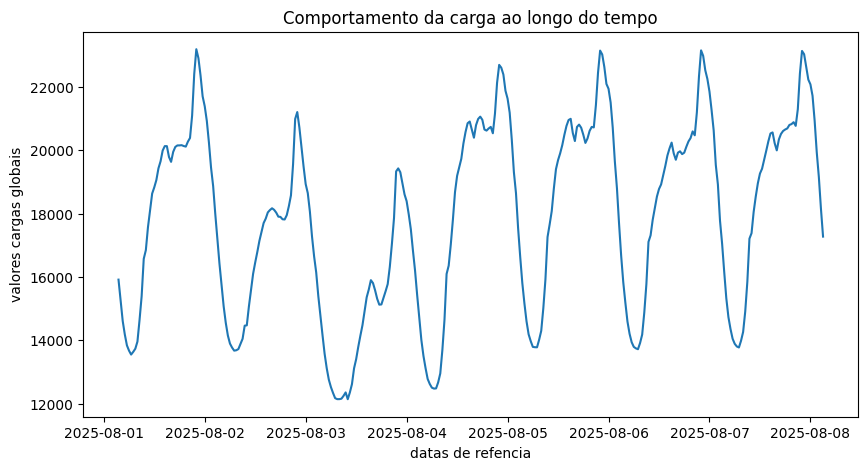

In [28]:
dados['din_referenciautc'] = pd.to_datetime(dados['din_referenciautc'])
dados_organizados = dados.sort_values("din_referenciautc")

plt.figure(figsize=(10,5))
plt.plot(dados_organizados.din_referenciautc, dados_organizados.val_cargaglobal)
plt.title("Comportamento da carga ao longo do tempo")
plt.xlabel("datas de refencia")
plt.ylabel("valores cargas globais")
plt.show()


### Interpretação do Gráfico 1: Comportamento da Carga ao Longo do Tempo

O gráfico exibe um padrão diário claro na carga elétrica de São Paulo ao longo da semana analisada (01/08/2025 a 07/08/2025). Observamos picos de demanda durante os dias úteis, geralmente no período da tarde/noite, e quedas significativas nas cargas durante as madrugadas e, notavelmente, nos dias 2 e 3 de agosto. Isso reflete o comportamento típico de consumo de energia, com maior atividade durante o horário comercial e residencial nos dias úteis, e menor atividade nos fins de semana.

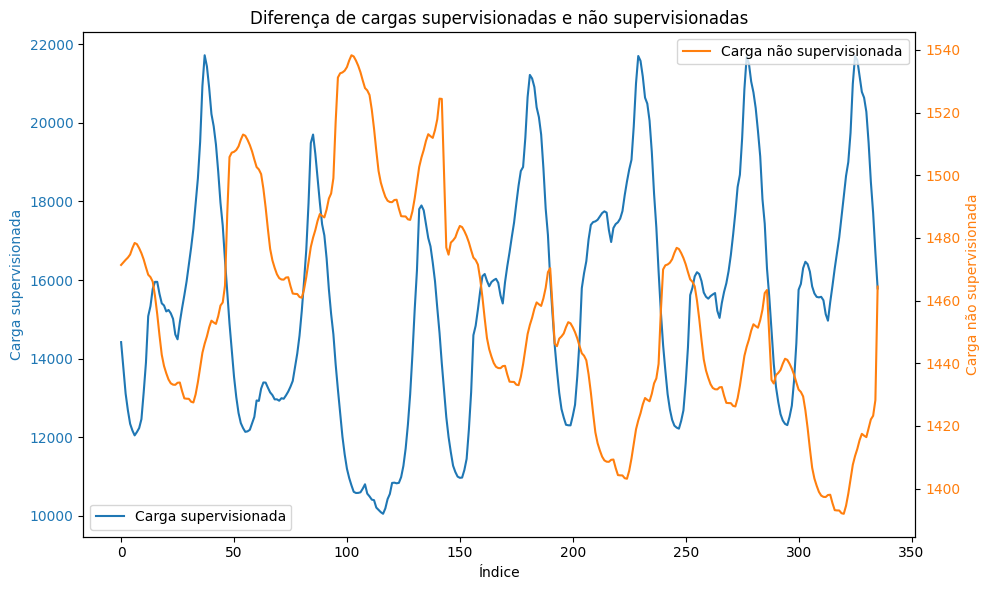

In [29]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Carga supervisionada (eixo esquerdo)
ax1.plot(dados.val_cargasupervisionada, color='tab:blue', label='Carga supervisionada')
ax1.set_xlabel('Índice')
ax1.set_ylabel('Carga supervisionada', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
plt.legend()

# Carga não supervisionada (eixo direito)
ax2 = ax1.twinx()
ax2.plot(dados.val_carganaosupervisionada, color='tab:orange', label='Carga não supervisionada')
ax2.set_ylabel('Carga não supervisionada', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title('Diferença de cargas supervisionadas e não supervisionadas')
fig.tight_layout()
plt.legend()
plt.show()

### Interpretação do Gráfico 2: Diferença de Cargas Supervisionadas e Não Supervisionadas

Este gráfico compara a carga elétrica supervisionada (azul) e não supervisionada (laranja) ao longo do período. Embora a carga supervisionada seja significativamente maior em magnitude, ambas as curvas seguem padrões sazonais e diários semelhantes. Isso sugere que as cargas não supervisionadas, embora menores, estão correlacionadas com a demanda geral de energia, provavelmente refletindo o consumo de setores ou atividades que, mesmo não sendo diretamente supervisionadas, acompanham o ritmo de uso de energia da região.

## DESAFIO 7 — Síntese para o relatório

Crie uma variável `resumo_resultados` contendo pelo menos:

- região;
- período;
- quantidade de registros;
- carga mínima;
- carga máxima;
- carga média;
- mediana;
- limiar de alta demanda;
- quantidade e percentual de alta demanda;
- momento do pico;
- resultado do segundo critério.

A IA deverá receber **resultados produzidos por vocês**, e não substituir a análise.

In [51]:
resumo_resultados = f'''Area carga: {parametros['cod_areacarga']}
Periodo analisado: {parametros['dat_inicio']} a {parametros['dat_fim']}
Quantidade de registros: {len(dados_novo)}
Carga minima: {carga_minima}
Carga maxima: {carga_maxima}
Carga media: {carga_media:.3f}
mediana: {mediana:.3f}
Limiar de alta demanda: {limiar:.3f}
Registros de alta demanda: {qtd_alta_demanda}
Percentual de alta demanda: {pct_alta_demanda:.3f}
Momento do pico: {horario_pico}
Segundo criterio: {linha} linhas e {coluna} colunas quando a carga estava acima da media.
'''
print(resumo_resultados)

Area carga: SP
Periodo analisado: 2025-08-01 a 2025-08-07
Quantidade de registros: 336
Carga minima: 12139.253
Carga maxima: 23185.312
Carga media: 17870.829
mediana: 18199.128
Limiar de alta demanda: 20866.781
Registros de alta demanda: 50
Percentual de alta demanda: 14.881
Momento do pico: 2025-08-01
Segundo criterio: 184 linhas e 4 colunas quando a carga estava acima da media.



# OPCIONAL: Relatório técnico com apoio do Gemini

No Colab:

1. abra **Secrets**;
2. crie `GEMINI_API_KEY`;
3. informe sua chave;
4. permita o acesso do notebook ao secret.

**Não coloque a chave diretamente no código.**

In [26]:
!pip -q install -U google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 4.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.57.0 which is incompatible.


In [27]:
from google.colab import userdata
from google import genai

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
client = genai.Client(api_key=GEMINI_API_KEY)

SecretNotFoundError: Secret GEMINI_API_KEY does not exist.

## DESAFIO 8 — Geração do relatório

O relatório deve:

- usar os resultados calculados;
- apresentar os principais indicadores;
- destacar o pico e os períodos de alta demanda;
- comparar os dois critérios;
- não inventar causas;
- diferenciar observações de hipóteses;
- terminar com uma conclusão.

In [ ]:
prompt = f'''
Atue como analista de dados do setor elétrico.

Produza um relatório técnico curto com base EXCLUSIVAMENTE nos resultados abaixo.

Não invente causas para as variações observadas.
Não apresente como fato explicações que não possam ser sustentadas pelos dados.
Diferencie claramente resultados observados de hipóteses.

Inclua:
1. caracterização do conjunto analisado;
2. principais indicadores;
3. análise dos períodos de alta demanda;
4. comparação com o segundo critério;
5. conclusão.

RESULTADOS DA EQUIPE:

{resumo_resultados}
'''

In [ ]:
response_gemini = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=prompt
)

print(response_gemini.text)

## DESAFIO 9 — Validação crítica

Compare o texto gerado pelo Gemini com os cálculos, DataFrames e gráficos.

Responda:

1. Os indicadores foram utilizados corretamente?
2. Há alguma afirmação que não pode ser confirmada pelos dados?
3. Houve interpretação exagerada ou causalidade não demonstrada?
4. Que alterações a equipe realizou no texto?

## Relatório final

Insira abaixo a versão final revisada pela equipe.

_Escreva aqui a versão final revisada._

---

## Entrega

O notebook deve apresentar:

- consulta à API executada;
- DataFrame criado;
- inspeção e organização dos dados;
- indicadores;
- pelo menos dois DataFrames derivados por critérios;
- percentuais;
- pelo menos dois gráficos;
- interpretações;
- síntese para a IA;
- relatório com apoio do Gemini;
- validação crítica;
- versão final revisada.

**Entregue somente este Notebook (.ipynb), com todas as células executadas e os resultados visíveis.**